Business Understanding
        ↓
Data Collection
        ↓
Dataset Understanding
        ↓
Data Cleaning
        ↓
Handle Missing Values
        ↓
Handle Outliers (if required)
        ↓
Exploratory Data Analysis (EDA)
        ↓
Feature Engineering (if required)
        ↓
Encoding (if categorical data)
        ↓
Define Features (X) and Target (y)
        ↓
Train-Validation-Test Split
        ↓
Feature Scaling (Normalization / Standardization)
        ↓
Convert to Tensors
        ↓
Create Dataset & DataLoader
        ↓
Design Neural Network Architecture
        ↓
Choose Loss Function
        ↓
Choose Optimizer
        ↓
Training Loop
        ↓
Validation
        ↓
Hyperparameter Tuning
        ↓
Model Evaluation
        ↓
Save Trained Model
        ↓
Inference / Prediction
        ↓
Deployment
        ↓
GitHub + README

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os


In [2]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

Using device: cuda


In [ ]:
# Colab setup — installs + GPU device + file upload
!pip install optuna -q

import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


from google.colab import files
uploaded = files.upload()  


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/425.6 kB ? eta -:--:--
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/265.9 kB ? eta -:--:--
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 265.9/265.9 kB 28.2 MB/s eta 0:00:00
Using device: cuda


Saving shipments_raw.csv to shipments_raw.csv


In [3]:
#data collection

df = pd.read_csv(r"C:\Users\shobh\Downloads\AI and DATA SCIENCE\𝗗𝗲𝗲𝗽 𝗟𝗲𝗮𝗿𝗻𝗶𝗻𝗴 𝗣𝗿𝗼𝗷𝗲𝗰𝘁𝘀\ANN Projects\Shipping Delay Prediction System v2\data\shipments_raw.csv", encoding="latin1")  
pd.set_option('display.max_columns', None)
df.sample(3)

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,Customer Country,Customer Email,Customer Fname,Customer Id,Customer Lname,Customer Password,Customer Segment,Customer State,Customer Street,Customer Zipcode,Department Id,Department Name,Latitude,Longitude,Market,Order City,Order Country,Order Customer Id,order date (DateOrders),Order Id,Order Item Cardprod Id,Order Item Discount,Order Item Discount Rate,Order Item Id,Order Item Product Price,Order Item Profit Ratio,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Order Region,Order State,Order Status,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
161870,TRANSFER,4,4,97.489998,299.970001,Shipping on time,0,9,Cardio Equipment,Caguas,Puerto Rico,XXXXXXXXX,Carol,3341,Smith,XXXXXXXXX,Consumer,PR,5888 Iron Goose Centre,725.0,3,Footwear,18.224901,-66.370613,Pacific Asia,Griffith,Australia,3341,12/5/2015 16:41,23203,191,0.0,0.00,58089,99.989998,0.33,3,299.970001,299.970001,97.489998,Oceania,Nueva Gales del Sur,PROCESSING,NaN,191,9,NaN,http://images.acmesports.sports/Nike+Men%27s+F...,Nike Men's Free 5.0+ Running Shoe,99.989998,0,12/9/2015 16:41,Standard Class
167275,PAYMENT,6,4,-29.830000,263.980011,Late delivery,1,43,Camping & Hiking,Waipahu,EE. UU.,XXXXXXXXX,Rebecca,3469,Harmon,XXXXXXXXX,Home Office,HI,5543 Clear Cloud Falls,96797.0,7,Fan Shop,21.390379,-158.004623,Pacific Asia,Foshan,China,3469,3/18/2016 0:04,30280,957,36.0,0.12,75661,299.980011,-0.11,1,299.980011,263.980011,-29.830000,Eastern Asia,Guangdong,PENDING_PAYMENT,NaN,957,43,NaN,http://images.acmesports.sports/Diamondback+Wo...,Diamondback Women's Serene Classic Comfort Bi,299.980011,0,3/24/2016 0:04,Standard Class
101586,PAYMENT,6,2,12.090000,46.480000,Late delivery,1,46,Indoor/Outdoor Games,Brandon,EE. UU.,XXXXXXXXX,Emily,154,May,XXXXXXXXX,Corporate,FL,6697 Thunder Dale Downs,33511.0,7,Fan Shop,27.883890,-82.297203,USCA,Reno,Estados Unidos,154,4/18/2016 16:19,32450,1014,3.5,0.07,81156,49.980000,0.26,1,49.980000,46.480000,12.090000,West of USA,Nevada,PENDING_PAYMENT,89502.0,1014,46,NaN,http://images.acmesports.sports/O%27Brien+Men%...,O'Brien Men's Neoprene Life Vest,49.980000,0,4/24/2016 16:19,Second Class


## <span style="color:#DC2626; font-family:Georgia;">Target Variable : (Late_delivery_risk)</span>

- **<span style="color:#16A34A;">0</span>** → **<span style="color:#2563EB;"> No Delay Risk</span>**
- **<span style="color:#DC2626;">1</span>** → **<span style="color:#EA580C;">Delay Risk</span>**

In [4]:
#dataset understanding

<h2 style="font-size:30px; color:#1E3A8A; border-bottom:2px solid #DBEAFE; padding-bottom:7px;">
    <strong>Dataset Column Descriptions</strong>
</h2>

<h3 style="color:#1D4ED8;">Order & Shipping Information</h3>

<div style="background:linear-gradient(135deg,#EFF6FF,#F5F3FF); border-left:5px solid #2563EB; padding:15px 18px; border-radius:8px; line-height:1.9;">

<strong>Type:</strong> Payment method used for the order, such as DEBIT or TRANSFER.<br>

<strong>Days for shipping (real):</strong> Actual number of days taken to deliver the order.<br>

<strong>Days for shipment (scheduled):</strong> Number of days that were planned for delivering the order.<br>

<strong>Delivery Status:</strong> Shows whether the shipment was delivered on time, delivered early, or delivered late.<br>

<strong>Late_delivery_risk:</strong> Indicates whether the order had a risk of late delivery. `1` means late-delivery risk and `0` means no late-delivery risk.<br>

<strong>order date (DateOrders):</strong> Date and time when the order was placed.<br>

<strong>shipping date (DateOrders):</strong> Date and time when the order was shipped.<br>

<strong>Shipping Mode:</strong> Shipping method selected for the order, such as <strong>Standard Class, Second Class, First Class, or Same Day</strong>.<br>

<strong>Order Status:</strong> Current status of the order, such as COMPLETE, PENDING, CANCELED, or other order states.

</div>

<h3 style="color:#15803D;">Product Information</h3>

<div style="background:linear-gradient(135deg,#F0FDF4,#ECFDF5); border-left:5px solid #16A34A; padding:15px 18px; border-radius:8px; line-height:1.9;">

<strong>Category Id:</strong> Numeric ID used to identify the product category.<br>

<strong>Category Name:</strong> Name of the category to which the product belongs.<br>

<strong>Department Id:</strong> Numeric ID used to identify the department containing the product.<br>

<strong>Department Name:</strong> Name of the department containing the product.<br>

<strong>Product Card Id:</strong> Numeric ID used to identify the product.<br>

<strong>Product Category Id:</strong> ID representing the category of the product.<br>

<strong>Product Description:</strong> Description of the product. In this dataset, this column contains missing values.<br>

<strong>Product Image:</strong> URL pointing to the product's image.<br>

<strong>Product Name:</strong> Name of the product.<br>

<strong>Product Price:</strong> Price of the product.<br>

<strong>Product Status:</strong> Indicates the status of the product. `0` generally represents an inactive/not-currently-available product in this dataset.

</div>

<h3 style="color:#A16207;">Customer Information</h3>

<div style="background:linear-gradient(135deg,#FEFCE8,#FFFBEB); border-left:5px solid #EAB308; padding:15px 18px; border-radius:8px; line-height:1.9;">

<strong>Customer City:</strong> City where the customer is located.<br>

<strong>Customer Country:</strong> Country where the customer is located.<br>

<strong>Customer Email:</strong> Email address associated with the customer.<br>

<strong>Customer Fname:</strong> First name of the customer.<br>

<strong>Customer Id:</strong> Unique ID assigned to the customer.<br>

<strong>Customer Lname:</strong> Last name of the customer.<br>

<strong>Customer Password:</strong> Password associated with the customer account.<br>

<strong>Customer Segment:</strong> Type of customer, such as <strong>Consumer, Corporate, or Home Office</strong>.<br>

<strong>Customer State:</strong> State where the customer is located.<br>

<strong>Customer Street:</strong> Street address of the customer.<br>

<strong>Customer Zipcode:</strong> ZIP/postal code of the customer's location.

</div>

<h3 style="color:#C2410C;">Order Information</h3>

<div style="background:linear-gradient(135deg,#FFF7ED,#FFEDD5); border-left:5px solid #F97316; padding:15px 18px; border-radius:8px; line-height:1.9;">

<strong>Order Id:</strong> Unique ID assigned to an order.<br>

<strong>Order Customer Id:</strong> ID of the customer who placed the order.<br>

<strong>Order Item Id:</strong> Unique ID assigned to an individual item within an order.<br>

<strong>Order Item Cardprod Id:</strong> ID of the product associated with the order item.<br>

<strong>Order Item Quantity:</strong> Number of units of the product purchased.<br>

<strong>Order Item Product Price:</strong> Price of the product for the order item.<br>

<strong>Order Item Discount:</strong> Discount amount applied to the order item.<br>

<strong>Order Item Discount Rate:</strong> Percentage/rate of discount applied to the order item.<br>

<strong>Order Item Total:</strong> Total value of the order item after considering its quantity and applicable discount.<br>

<strong>Order Item Profit Ratio:</strong> Ratio representing the profit generated from the order item.<br>

<strong>Order Profit Per Order:</strong> Profit generated from the order.<br>

<strong>Sales:</strong> Total sales/revenue generated from the order.<br>

<strong>Sales per customer:</strong> Total sales amount associated with the customer/order.<br>

<strong>Benefit per order:</strong> Benefit or profit generated from the order after considering relevant costs.

</div>

<h3 style="color:#B91C1C;">Order Location Information</h3>

<div style="background:linear-gradient(135deg,#FEF2F2,#FFF1F2); border-left:5px solid #EF4444; padding:15px 18px; border-radius:8px; line-height:1.9;">

<strong>Order City:</strong> City where the order is being delivered.<br>

<strong>Order Country:</strong> Country where the order is being delivered.<br>

<strong>Order Region:</strong> Geographical region where the order is being delivered.<br>

<strong>Order State:</strong> State or region where the order is being delivered.<br>

<strong>Order Zipcode:</strong> ZIP/postal code of the order's delivery location.

</div>

<h3 style="color:#7E22CE;">Geographic Information</h3>

<div style="background:linear-gradient(135deg,#FAF5FF,#F5F3FF); border-left:5px solid #9333EA; padding:15px 18px; border-radius:8px; line-height:1.9;">

<strong>Latitude:</strong> Latitude coordinate representing the customer's geographical location.<br>

<strong>Longitude:</strong> Longitude coordinate representing the customer's geographical location.<br>

<strong>Market:</strong> Business/geographical market associated with the order.

</div>

<h3 style="color:#57534E;">Other Identifiers & Financial Information</h3>

<div style="background:linear-gradient(135deg,#FAFAF9,#F5F5F4); border-left:5px solid #78716C; padding:15px 18px; border-radius:8px; line-height:1.9;">

<strong>Customer Id:</strong> Unique identifier for the customer.<br>

<strong>Category Id:</strong> Unique identifier for the product category.<br>

<strong>Department Id:</strong> Unique identifier for the product department.<br>

<strong>Product Card Id:</strong> Unique identifier for the product.<br>

<strong>Product Category Id:</strong> Identifier representing the product's category.

</div>

In [5]:
df.sample(8)

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,Customer Country,Customer Email,Customer Fname,Customer Id,Customer Lname,Customer Password,Customer Segment,Customer State,Customer Street,Customer Zipcode,Department Id,Department Name,Latitude,Longitude,Market,Order City,Order Country,Order Customer Id,order date (DateOrders),Order Id,Order Item Cardprod Id,Order Item Discount,Order Item Discount Rate,Order Item Id,Order Item Product Price,Order Item Profit Ratio,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Order Region,Order State,Order Status,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
172913,CASH,6,2,-28.700001,38.790001,Late delivery,1,29,Shop By Sport,Caguas,Puerto Rico,XXXXXXXXX,Mary,3111,Brown,XXXXXXXXX,Consumer,PR,8344 Sunny Embers Point,725.0,5,Golf,18.272326,-66.370583,Europe,Bari,Italia,3111,7/9/2017 3:37,63035,627,1.20,0.03,157611,39.990002,-0.74,1,39.990002,38.790001,-28.700001,Southern Europe,Apulia,CLOSED,NaN,627,29,NaN,http://images.acmesports.sports/Under+Armour+G...,Under Armour Girls' Toddler Spine Surge Runni,39.990002,0,7/15/2017 3:37,Second Class
1898,TRANSFER,3,4,79.849998,236.250000,Shipping canceled,0,24,Women's Apparel,Caguas,Puerto Rico,XXXXXXXXX,Walter,4775,Wright,XXXXXXXXX,Consumer,PR,7668 Rustic Route,725.0,5,Golf,18.257147,-66.370499,Pacific Asia,Albany,Australia,4775,2/23/2016 14:28,28677,502,13.75,0.06,71777,50.000000,0.34,5,250.000000,236.250000,79.849998,Oceania,Australia Occidental,SUSPECTED_FRAUD,NaN,502,24,NaN,http://images.acmesports.sports/Nike+Men%27s+D...,Nike Men's Dri-FIT Victory Golf Polo,50.000000,0,2/26/2016 14:28,Standard Class
138034,DEBIT,4,2,138.589996,395.980011,Late delivery,1,45,Fishing,Caguas,Puerto Rico,XXXXXXXXX,Mary,3373,Willis,XXXXXXXXX,Consumer,PR,9749 Red Barn Harbour,725.0,7,Fan Shop,18.255585,-66.370590,LATAM,San Salvador,El Salvador,3373,4/23/2017 18:36,57803,1004,4.00,0.01,144625,399.980011,0.35,1,399.980011,395.980011,138.589996,Central America,San Salvador,ON_HOLD,NaN,1004,45,NaN,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,4/27/2017 18:36,Second Class
15489,TRANSFER,4,4,18.980000,167.960007,Shipping on time,0,29,Shop By Sport,Los Angeles,EE. UU.,XXXXXXXXX,Mary,12251,Hinton,XXXXXXXXX,Consumer,CA,5292 Misty Goose Street,90047.0,5,Golf,33.943520,-118.310326,LATAM,Mejicanos,El Salvador,12251,1/20/2015 21:10,1363,627,31.99,0.16,3371,39.990002,0.11,5,199.949997,167.960007,18.980000,Central America,San Salvador,PENDING,NaN,627,29,NaN,http://images.acmesports.sports/Under+Armour+G...,Under Armour Girls' Toddler Spine Surge Runni,39.990002,0,1/24/2015 21:10,Standard Class
130705,DEBIT,1,0,20.790001,79.970001,Late delivery,1,46,Indoor/Outdoor Games,Mililani,EE. UU.,XXXXXXXXX,Elizabeth,7863,Hodges,XXXXXXXXX,Home Office,HI,4542 Sunny Parade,96789.0,7,Fan Shop,21.447960,-158.016037,USCA,Philadelphia,Estados Unidos,7863,4/13/2016 18:57,32115,1014,19.99,0.20,80309,49.980000,0.26,2,99.959999,79.970001,20.790001,East of USA,Pensilvania,COMPLETE,19140.0,1014,46,NaN,http://images.acmesports.sports/O%27Brien+Men%...,O'Brien Men's Neoprene Life Vest,49.980000,0,4/14/2016 6:57,Same Day
97912,DEBIT,5,2,23.270000,49.500000,Late delivery,1,24,Women's Apparel,Cleveland,EE. UU.,XXXXXXXXX,Mary,9050,Smith,XXXXXXXXX,Home Office,OH,1131 Cotton Grounds,44109.0,5,Golf,41.436409,-81.706657,USCA,Seattle,Estados Unidos,9050,6/13/2016 1:32,36244,502,0.50,0.01,90502,50.000000,0.47,1,50.000000,49.500000,23.270000,West of USA,Washington,ON_HOLD,98115.0,502,24,NaN,http://images.acmesports.sports/Nike+Men%27s+D...,Nike Men's Dri-FIT Victory Golf Polo,50.000000,0,6/18/2016 1:32,Second Class
60585,DEBIT,4,4,120.949997,251.979996,Shipping on time,0,43,Camping & Hiking,Houston,EE. U

In [6]:
#data cleaning

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 53 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Type                           180519 non-null  object 
 1   Days for shipping (real)       180519 non-null  int64  
 2   Days for shipment (scheduled)  180519 non-null  int64  
 3   Benefit per order              180519 non-null  float64
 4   Sales per customer             180519 non-null  float64
 5   Delivery Status                180519 non-null  object 
 6   Late_delivery_risk             180519 non-null  int64  
 7   Category Id                    180519 non-null  int64  
 8   Category Name                  180519 non-null  object 
 9   Customer City                  180519 non-null  object 
 10  Customer Country               180519 non-null  object 
 11  Customer Email                 180519 non-null  object 
 12  Customer Fname                

In [8]:
df.describe()

,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Late_delivery_risk,Category Id,Customer Id,Customer Zipcode,Department Id,Latitude,Longitude,Order Customer Id,Order Id,Order Item Cardprod Id,Order Item Discount,Order Item Discount Rate,Order Item Id,Order Item Product Price,Order Item Profit Ratio,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Price,Product Status
count,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180516.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,24840.000000,180519.000000,180519.000000,0.0,180519.000000,180519.0
mean,3.497654,2.931847,21.974989,183.107609,0.548291,31.851451,6691.379495,35921.126914,5.443460,29.719955,-84.915675,6691.379495,36221.894903,692.509764,20.664741,0.101668,90260.000000,141.232550,0.120647,2.127638,203.772096,183.107609,21.974989,55426.132327,692.509764,31.851451,NaN,141.232550,0.0
std,1.623722,1.374449,104.433526,120.043670,0.497664,15.640064,4162.918106,37542.461122,1.629246,9.813646,21.433241,4162.918106,21045.379569,336.446807,21.800901,0.070415,52111.490959,139.732492,0.466796,1.453451,132.273077,120.043670,104.433526,31919.279101,336.446807,15.640064,NaN,139.732492,0.0
min,0.000000,0.000000,-4274.979980,7.490000,0.000000,2.000000,1.000000,603.000000,2.000000,-33.937553,-158.025986,1.000000,1.000000,19.000000,0.000000,0.000000,1.000000,9.990000,-2.750000,1.000000,9.990000,7.490000,-4274.979980,1040.000000,19.000000,2.000000,NaN,9.990000,0.0
25%,2.000000,2.000000,7.000000,104.379997,0.000000,18.000000,3258.500000,725.000000,4.000000,18.265432,-98.446312,3258.500000,18057.000000,403.000000,5.400000,0.040000,45130.500000,50.000000,0.080000,1.000000,119.980003,104.379997,7.000000,23464.000000,403.000000,18.000000,NaN,50.000000,0.0
50%,3.000000,4.000000,31.520000,163.990005,1.000000,29.000000,6457.000000,19380.000000,5.000000,33.144863,-76.847908,6457.000000,36140.000000,627.000000,14.000000,0.100000,90260.000000,59.990002,0.270000,1.000000,199.919998,163.990005,31.520000,59405.000000,627.000000,29.000000,NaN,59.990002,0.0
75%,5.000000,4.000000,64.800003,247.399994,1.000000,45.000000,9779.000000,78207.000000,7.000000,39.279617,-66.370583,9779.000000,54144.000000,1004.000000,29.990000,0.160000,135389.500000,199.990005,0.360000,3.000000,299.950012,247.399994,64.800003,90008.000000,1004.000000,45.000000,NaN,199.990005,0.0
max,6.000000,4.000000,911.799988,1939.989990,1.000000,76.000000,20757.000000,99205.000000,12.000000,48.781933,115.263077,20757.000000,77204.000000,1363.000000,500.000000,0.250000,180519.000000,1999.989990,0.500000,5.000000,1999.989990,1939.989990,911.799988,99301.000000,1363.000000,76.000000,NaN,1999.989990,0.0


In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.isnull().sum()

Type                                  0
Days for shipping (real)              0
Days for shipment (scheduled)         0
Benefit per order                     0
Sales per customer                    0
Delivery Status                       0
Late_delivery_risk                    0
Category Id                           0
Category Name                         0
Customer City                         0
Customer Country                      0
Customer Email                        0
Customer Fname                        0
Customer Id                           0
Customer Lname                        8
Customer Password                     0
Customer Segment                      0
Customer State                        0
Customer Street                       0
Customer Zipcode                      3
Department Id                         0
Department Name                       0
Latitude                              0
Longitude                             0
Market                                0


In [11]:
print(df['Product Description'].isnull().sum())

df['Product Description'].sample(60)

180519


145322   NaN
18630    NaN
170815   NaN
6262     NaN
159815   NaN
59406    NaN
125029   NaN
76538    NaN
14487    NaN
119030   NaN
72010    NaN
28027    NaN
169403   NaN
173818   NaN
63850    NaN
162895   NaN
16082    NaN
40534    NaN
60743    NaN
147820   NaN
92531    NaN
96051    NaN
79558    NaN
146553   NaN
166705   NaN
24516    NaN
110309   NaN
172110   NaN
121740   NaN
128389   NaN
81369    NaN
49064    NaN
178088   NaN
78162    NaN
163687   NaN
150341   NaN
53852    NaN
38537    NaN
59748    NaN
14212    NaN
62770    NaN
57265    NaN
178693   NaN
89080    NaN
175013   NaN
162412   NaN
150510   NaN
166878   NaN
121913   NaN
122732   NaN
49380    NaN
89055    NaN
39833    NaN
28083    NaN
72211    NaN
20322    NaN
41093    NaN
138819   NaN
90191    NaN
174220   NaN
Name: Product Description, dtype: float64

In [12]:
# print(df['Order Zipcode'].isnull().sum())

# df['Order Zipcode'].sample(60)



# #will give error now

In [13]:
df.drop(columns=['Order Zipcode'], inplace=True, errors='ignore')
df.drop(columns=['Product Description'], inplace=True, errors='ignore')

In [14]:
df.sample(2)

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,Customer Country,Customer Email,Customer Fname,Customer Id,Customer Lname,Customer Password,Customer Segment,Customer State,Customer Street,Customer Zipcode,Department Id,Department Name,Latitude,Longitude,Market,Order City,Order Country,Order Customer Id,order date (DateOrders),Order Id,Order Item Cardprod Id,Order Item Discount,Order Item Discount Rate,Order Item Id,Order Item Product Price,Order Item Profit Ratio,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Order Region,Order State,Order Status,Product Card Id,Product Category Id,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
80952,TRANSFER,6,4,39.509998,165.990005,Late delivery,1,48,Water Sports,Caguas,Puerto Rico,XXXXXXXXX,Charles,4759,Lowe,XXXXXXXXX,Corporate,PR,421 Pleasant Diversion,725.0,7,Fan Shop,18.222420,-66.370499,Pacific Asia,Marikina,Filipinas,4759,2/4/2016 17:50,27385,1073,34.0,0.17,68581,199.990005,0.24,1,199.990005,165.990005,39.509998,Southeast Asia,Capital Nacional,PENDING,1073,48,http://images.acmesports.sports/Pelican+Sunstr...,Pelican Sunstream 100 Kayak,199.990005,0,2/10/2016 17:50,Standard Class
119798,TRANSFER,4,2,84.379997,225.000000,Late delivery,1,24,Women's Apparel,Lawton,EE. UU.,XXXXXXXXX,Frank,1843,Garcia,XXXXXXXXX,Consumer,OK,5430 Burning Rise Route,73505.0,5,Golf,34.621593,-98.469292,Europe,Cormeilles-en-Parisis,Francia,1843,8/28/2015 8:35,16398,502,25.0,0.10,40951,50.000000,0.38,5,250.000000,225.000000,84.379997,Western Europe,Isla de Francia,PENDING,502,24,http://images.acmesports.sports/Nike+Men%27s+D...,Nike Men's Dri-FIT Victory Golf Polo,50.000000,0,9/1/2015 8:35,Second Class


In [15]:
df['Delivery Status'].value_counts()

Delivery Status
Late delivery        98977
Advance shipping     41592
Shipping on time     32196
Shipping canceled     7754
Name: count, dtype: int64

In [16]:
df['Category Name'].value_counts()

Category Name
Cleats                  24551
Men's Footwear          22246
Women's Apparel         21035
Indoor/Outdoor Games    19298
Fishing                 17325
Water Sports            15540
Camping & Hiking        13729
Cardio Equipment        12487
Shop By Sport           10984
Electronics              3156
Accessories              1780
Golf Balls               1475
Girls' Apparel           1201
Golf Gloves              1070
Trade-In                  974
Video Games               838
Children's Clothing       652
Women's Clothing          650
Baseball & Softball       632
Hockey                    614
Cameras                   592
Toys                      529
Golf Shoes                524
Pet Supplies              492
Crafts                    484
Garden                    484
DVDs                      483
Computers                 442
Golf Apparel              441
Hunting & Shooting        440
Music                     434
Consumer Electronics      431
Boxing & MMA              

<h2 style="font-size:30px; color:#1E3A8A; border-bottom:2px solid #DBEAFE; padding-bottom:8px;">
    <strong>Column Selection for Neural Network Training</strong>
</h2>

<div style="
    background:linear-gradient(135deg,#EFF6FF,#F5F3FF);
    border-left:6px solid #2563EB;
    border-radius:10px;
    padding:16px 20px;
    margin:18px 0;
">

<strong>Now we will remove all columns that are not useful for our Neural Network training.</strong>

</div>

<h3 style="font-size:23px; color:#166534;">
    <strong>Column Selection</strong>
</h3>

<table style="width:100%; border-collapse:separate; border-spacing:6px; line-height:1.6;">

<tr>
<th style="padding:10px; background:#E5E7EB;">Column</th>
<th style="padding:10px; background:#E5E7EB;">Decision</th>
</tr>

<tr><td style="padding:8px;">Type</td><td style="padding:8px; background:#DCFCE7;"><strong>Useful</strong></td></tr>
<tr><td style="padding:8px;">Days for shipping (real)</td><td style="padding:8px; background:#FEE2E2;"><strong>Useless</strong> — data leakage</td></tr>
<tr><td style="padding:8px;">Days for shipment (scheduled)</td><td style="padding:8px; background:#DCFCE7;"><strong>Useful</strong></td></tr>
<tr><td style="padding:8px;">Benefit per order</td><td style="padding:8px; background:#DCFCE7;"><strong>Useful</strong></td></tr>
<tr><td style="padding:8px;">Sales per customer</td><td style="padding:8px; background:#DCFCE7;"><strong>Useful</strong></td></tr>
<tr><td style="padding:8px;">Delivery Status</td><td style="padding:8px; background:#FEE2E2;"><strong>Useless</strong> — data leakage</td></tr>
<tr><td style="padding:8px;">Late_delivery_risk</td><td style="padding:8px; background:#FEF3C7;"><strong>Target Variable</strong></td></tr>
<tr><td style="padding:8px;">Category Id</td><td style="padding:8px; background:#FEE2E2;"><strong>Useless</strong> — we will remove it</td></tr>
<tr><td style="padding:8px;">Category Name</td><td style="padding:8px; background:#DCFCE7;"><strong>Useful</strong></td></tr>
<tr><td style="padding:8px;">Customer City</td><td style="padding:8px; background:#DCFCE7;"><strong>Useful</strong></td></tr>
<tr><td style="padding:8px;">Customer Country</td><td style="padding:8px; background:#DCFCE7;"><strong>Useful</strong></td></tr>
<tr><td style="padding:8px;">Customer Email</td><td style="padding:8px; background:#FEE2E2;"><strong>Useless</strong></td></tr>
<tr><td style="padding:8px;">Customer Fname</td><td style="padding:8px; background:#FEE2E2;"><strong>Useless</strong></td></tr>
<tr><td style="padding:8px;">Customer Id</td><td style="padding:8px; background:#FEE2E2;"><strong>Useless</strong></td></tr>
<tr><td style="padding:8px;">Customer Lname</td><td style="padding:8px; background:#FEE2E2;"><strong>Useless</strong></td></tr>
<tr><td style="padding:8px;">Customer Password</td><td style="padding:8px; background:#FEE2E2;"><strong>Useless</strong></td></tr>
<tr><td style="padding:8px;">Customer Segment</td><td style="padding:8px; background:#DCFCE7;"><strong>Useful</strong></td></tr>
<tr><td style="padding:8px;">Customer State</td><td style="padding:8px; background:#DCFCE7;"><strong>Useful</strong></td></tr>
<tr><td style="padding:8px;">Customer Street</td><td style="padding:8px; background:#FEE2E2;"><strong>Useless</strong></td></tr>
<tr><td style="padding:8px;">Customer Zipcode</td><td style="padding:8px; background:#FEE2E2;"><strong>Useless</strong></td></tr>
<tr><td style="padding:8px;">Department Id</td><td style="padding:8px; background:#FEE2E2;"><strong>Useless</strong></td></tr>
<tr><td style="padding:8px;">Department Name</td><td style="padding:8px; background:#DCFCE7;"><strong>Useful</strong></td></tr>
<tr><td style="padding:8px;">Latitude</td><td style="padding:8px; background:#DCFCE7;"><strong>Useful</strong></td></tr>
<tr><td style="padding:8px;">Longitude</td><td style="padding:8px; background:#DCFCE7;"><strong>Useful</strong></td></tr>
<tr><td style="padding:8px;">Market</td><td style="padding:8px; background:#DCFCE7;"><strong>Useful</strong></td></tr>
<tr><td style="padding:8px;">Order City</td><td style="padding:8px; background:#DCFCE7;"><strong>Useful</strong></td></tr>
<tr><td style="padding:8px;">Order Country</td><td style="padding:8px; background:#DCFCE7;"><strong>Useful</strong></td></tr>
<tr><td style="padding:8px;">Order Customer Id</td><td style="padding:8px; background:#FEE2E2;"><strong>Useless</strong></td></tr>
<tr><td style="padding:8px;">order date (DateOrders)</td><td style="padding:8px; background:#FEE2E2;"><strong>Useless</strong></td></tr>
<tr><td style="padding:8px;">Order Id</td><td style="padding:8px; background:#FEE2E2;"><strong>Useless</strong></td></tr>
<tr><td style="padding:8px;">Order Item Cardprod Id</td><td style="padding:8px; background:#FEE2E2;"><strong>Useless</strong></td></tr>
<tr><td style="padding:8px;">Order Item Discount</td><td style="padding:8px; background:#DCFCE7;"><strong>Useful</strong></td></tr>
<tr><td style="padding:8px;">Order Item Discount Rate</td><td style="padding:8px; background:#DCFCE7;"><strong>Useful</strong></td></tr>
<tr><td style="padding:8px;">Order Item Id</td><td style="padding:8px; background:#FEE2E2;"><strong>Useless</strong></td></tr>
<tr><td style="padding:8px;">Order Item Product Price</td><td style="padding:8px; background:#DCFCE7;"><strong>Useful</strong></td></tr>
<tr><td style="padding:8px;">Order Item Profit Ratio</td><td style="padding:8px; background:#DCFCE7;"><strong>Useful</strong></td></tr>
<tr><td style="padding:8px;">Order Item Quantity</td><td style="padding:8px; background:#DCFCE7;"><strong>Useful</strong></td></tr>
<tr><td style="padding:8px;">Sales</td><td style="padding:8px; background:#DCFCE7;"><strong>Useful</strong></td></tr>
<tr><td style="padding:8px;">Order Item Total</td><td style="padding:8px; background:#DCFCE7;"><strong>Useful</strong></td></tr>
<tr><td style="padding:8px;">Order Profit Per Order</td><td style="padding:8px; background:#DCFCE7;"><strong>Useful</strong></td></tr>
<tr><td style="padding:8px;">Order Region</td><td style="padding:8px; background:#DCFCE7;"><strong>Useful</strong></td></tr>
<tr><td style="padding:8px;">Order State</td><td style="padding:8px; background:#DCFCE7;"><strong>Useful</strong></td></tr>
<tr><td style="padding:8px;">Order Status</td><td style="padding:8px; background:#FEE2E2;"><strong>Useless</strong> — possible data leakage</td></tr>
<tr><td style="padding:8px;">Product Card Id</td><td style="padding:8px; background:#FEE2E2;"><strong>Useless</strong></td></tr>
<tr><td style="padding:8px;">Product Category Id</td><td style="padding:8px; background:#FEE2E2;"><strong>Useless</strong></td></tr>
<tr><td style="padding:8px;">Product Image</td><td style="padding:8px; background:#FEE2E2;"><strong>Useless</strong></td></tr>
<tr><td style="padding:8px;">Product Name</td><td style="padding:8px; background:#FEE2E2;"><strong>Useless</strong></td></tr>
<tr><td style="padding:8px;">Product Price</td><td style="padding:8px; background:#DCFCE7;"><strong>Useful</strong></td></tr>
<tr><td style="padding:8px;">Product Status</td><td style="padding:8px; background:#FEE2E2;"><strong>Useless</strong></td></tr>
<tr><td style="padding:8px;">shipping date (DateOrders)</td><td style="padding:8px; background:#FEE2E2;"><strong>Useless</strong> — data leakage</td></tr>
<tr><td style="padding:8px;">Shipping Mode</td><td style="padding:8px; background:#DCFCE7;"><strong>Useful</strong></td></tr>

</table>

In [17]:
df['Product Name'].nunique()

118

In [18]:
#now lets drop useless columns
useless_columns = ['Days for shipping (real)', 'Delivery Status', 'Category Id', 'Customer Email', 'Customer Fname', 'Customer Id',
                    'Customer Lname', 'Customer Password', 'Customer Street', 'Customer Zipcode', 'Department Id', 'Order Customer Id',
                    'order date (DateOrders)', 'Order Id', 'Order Item Cardprod Id', 'Order Item Id', 'Order Status', 'Product Card Id',
                    'Product Category Id', 'Product Image', 'Product Name',
                    'Product Status', 'shipping date (DateOrders)']

df.drop(columns=useless_columns, inplace=True)

df.shape

(180519, 28)

In [19]:
df.columns


Index(['Type', 'Days for shipment (scheduled)', 'Benefit per order',
       'Sales per customer', 'Late_delivery_risk', 'Category Name',
       'Customer City', 'Customer Country', 'Customer Segment',
       'Customer State', 'Department Name', 'Latitude', 'Longitude', 'Market',
       'Order City', 'Order Country', 'Order Item Discount',
       'Order Item Discount Rate', 'Order Item Product Price',
       'Order Item Profit Ratio', 'Order Item Quantity', 'Sales',
       'Order Item Total', 'Order Profit Per Order', 'Order Region',
       'Order State', 'Product Price', 'Shipping Mode'],
      dtype='object')

In [21]:
#next step : Hanlde missing values (already done )

#next step : Hanlde missing values (already done )

df_cleaned = df.copy()

# df_cleaned.to_csv(
#     "/content/shipment_dataset_cleaned.csv",
#     index=False)

In [22]:
#eda 


sns.set_style("whitegrid")

GRAPH_DIR = r"C:\Users\shobh\Downloads\AI and DATA SCIENCE\𝗗𝗲𝗲𝗽 𝗟𝗲𝗮𝗿𝗻𝗶𝗻𝗴 𝗣𝗿𝗼𝗷𝗲𝗰𝘁𝘀\ANN Projects\Shipping Delay Prediction System v2\graphs"
os.makedirs(GRAPH_DIR, exist_ok=True)

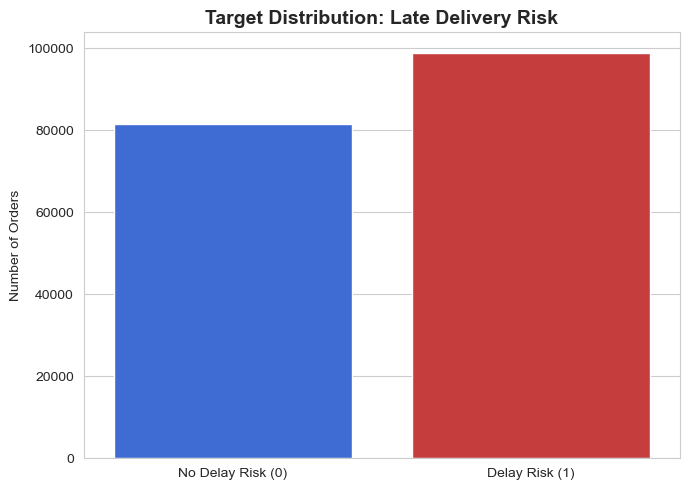

In [23]:
plt.figure(figsize=(7, 5))
ax = sns.countplot(data=df, x='Late_delivery_risk', hue='Late_delivery_risk',
                    palette=['#2563EB', '#DC2626'], legend=False)
ax.set_xticks([0, 1])
ax.set_xticklabels(['No Delay Risk (0)', 'Delay Risk (1)'])
plt.title('Target Distribution: Late Delivery Risk', fontsize=14, fontweight='bold')
plt.xlabel('')
plt.ylabel('Number of Orders')
plt.tight_layout()
plt.savefig(f"{GRAPH_DIR}/01_target_distribution.png", dpi=150)
plt.show()

<h2 style="font-size:26px; color:#1E3A8A; border-bottom:2px solid #DBEAFE; padding-bottom:7px;">
    <strong>Observation 1 — Target Distribution</strong>
</h2>

<div style="background:linear-gradient(135deg,#EFF6FF,#F5F3FF); border-left:5px solid #2563EB; padding:15px 18px; border-radius:8px; line-height:1.9;">

The classes are <strong style="color:#16A34A;">fairly balanced</strong> — about <strong>54.8%</strong> of orders carry a late-delivery risk (<code>1</code>) vs <strong>45.2%</strong> with no risk (<code>0</code>). No heavy class imbalance here, so accuracy is a reasonably trustworthy metric and we didn't need oversampling/undersampling.

</div>

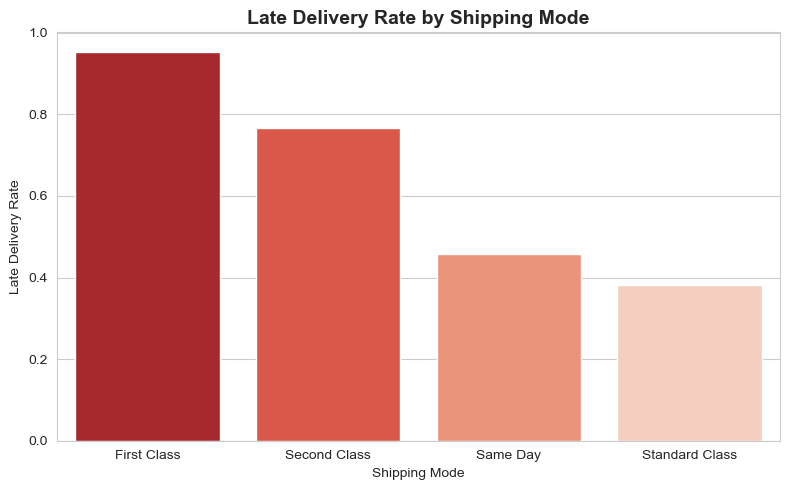

In [25]:
plt.figure(figsize=(8, 5))
mode_risk = df.groupby('Shipping Mode')['Late_delivery_risk'].mean().sort_values(ascending=False)
ax = sns.barplot(x=mode_risk.index, y=mode_risk.values, hue=mode_risk.index,
                  palette='Reds_r', legend=False)
plt.title('Late Delivery Rate by Shipping Mode', fontsize=14, fontweight='bold')
plt.ylabel('Late Delivery Rate')
plt.xlabel('Shipping Mode')
plt.tight_layout()
plt.savefig(f"{GRAPH_DIR}/02_shipping_mode_vs_risk.png", dpi=150)
plt.show()

<h2 style="font-size:26px; color:#991B1B; border-bottom:2px solid #FEE2E2; padding-bottom:7px;">
    <strong>Observation 2 — Shipping Mode is the biggest driver</strong>
</h2>

<div style="background:linear-gradient(135deg,#FEF2F2,#FFF1F2); border-left:5px solid #EF4444; padding:15px 18px; border-radius:8px; line-height:1.9;">

<strong style="color:#DC2626;">First Class</strong> orders are late <strong>95.3%</strong> of the time, <strong style="color:#EA580C;">Second Class</strong> <strong>76.6%</strong>, while <strong style="color:#16A34A;">Standard Class</strong> is only late <strong>38.1%</strong> of the time. Faster promised shipping = much higher chance of missing it — makes business sense (tighter deadline, less slack) and this is clearly the strongest signal in the dataset.

</div>

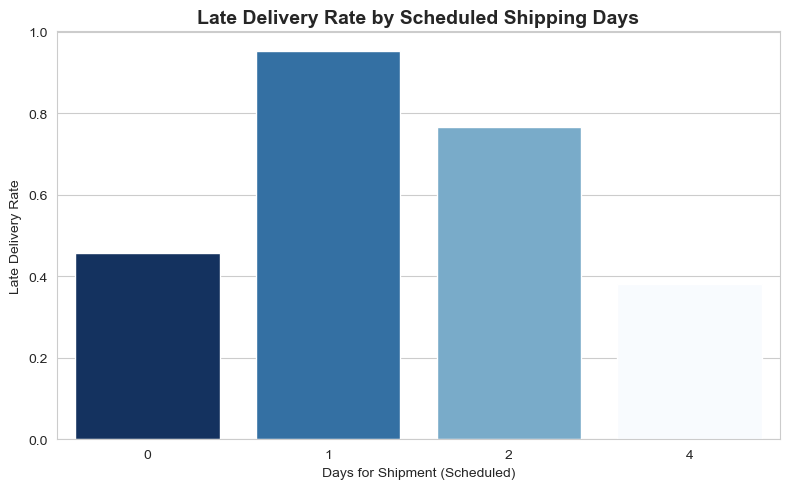

In [26]:
plt.figure(figsize=(8, 5))
days_risk = df.groupby('Days for shipment (scheduled)')['Late_delivery_risk'].mean().sort_index()
ax = sns.barplot(x=days_risk.index, y=days_risk.values, hue=days_risk.index,
                  palette='Blues_r', legend=False)
plt.title('Late Delivery Rate by Scheduled Shipping Days', fontsize=14, fontweight='bold')
plt.ylabel('Late Delivery Rate')
plt.xlabel('Days for Shipment (Scheduled)')
plt.tight_layout()
plt.savefig(f"{GRAPH_DIR}/03_scheduled_days_vs_risk.png", dpi=150)
plt.show()

<h2 style="font-size:26px; color:#1D4ED8; border-bottom:2px solid #DBEAFE; padding-bottom:7px;">
    <strong>Observation 3 — Confirms Graph 2</strong>
</h2>

<div style="background:linear-gradient(135deg,#EFF6FF,#F5F3FF); border-left:5px solid #2563EB; padding:15px 18px; border-radius:8px; line-height:1.9;">

This is basically the same story as Shipping Mode, from a different column: <strong>1-day scheduled shipping</strong> is late <strong>95%</strong> of the time, while <strong>4-day scheduled shipping</strong> is late only <strong>38%</strong> of the time. The two columns are nearly redundant — the tighter the promised window, the higher the risk.

</div>

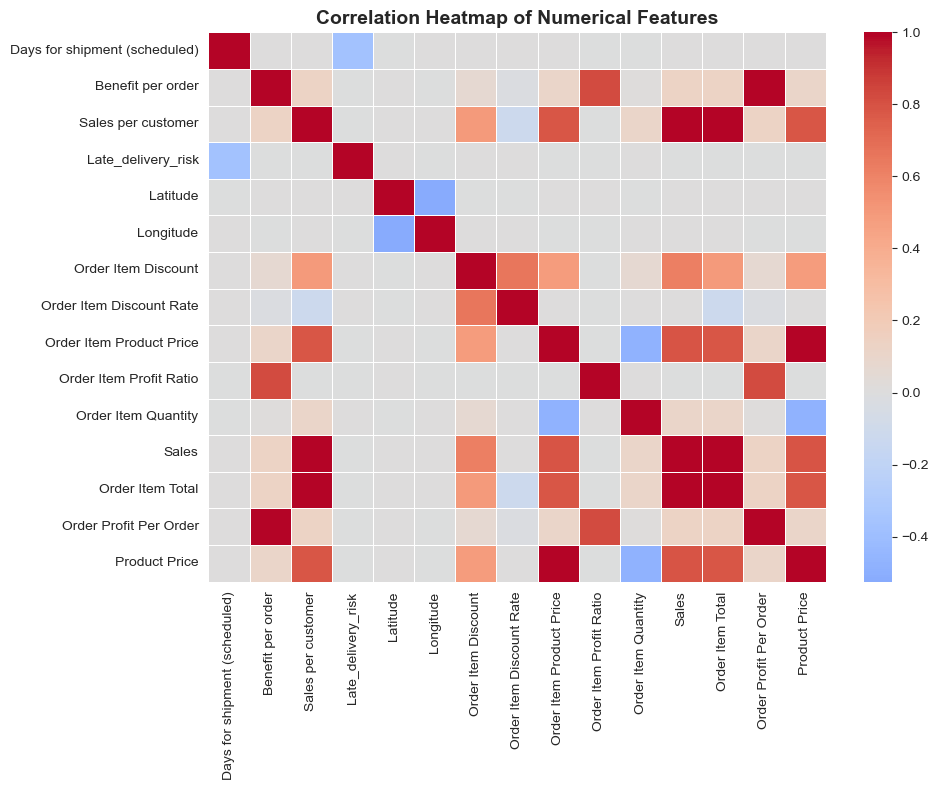

In [27]:
plt.figure(figsize=(10, 8))
num_df = df.select_dtypes(include='number')
corr = num_df.corr()
sns.heatmap(corr, cmap='coolwarm', center=0, linewidths=0.4)
plt.title('Correlation Heatmap of Numerical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{GRAPH_DIR}/04_correlation_heatmap.png", dpi=150)
plt.show()

<h2 style="font-size:26px; color:#166534; border-bottom:2px solid #DCFCE7; padding-bottom:7px;">
    <strong>Observation 4 — Only one feature really correlates with the target</strong>
</h2>

<div style="background:linear-gradient(135deg,#F0FDF4,#ECFDF5); border-left:5px solid #16A34A; padding:15px 18px; border-radius:8px; line-height:1.9;">

<strong>Days for shipment (scheduled)</strong> is the only numerical feature with a meaningful correlation to <code>Late_delivery_risk</code> (<strong>-0.37</strong>). Every other numeric column — Sales, Benefit per order, Discount, Profit Ratio, Latitude/Longitude — sits near <strong>0.00</strong>. This tells us the ANN is mostly leaning on shipping-speed information; the financial/geographic columns add little signal on their own (they likely help more through interactions the network can learn, which a simple correlation won't catch).

</div>

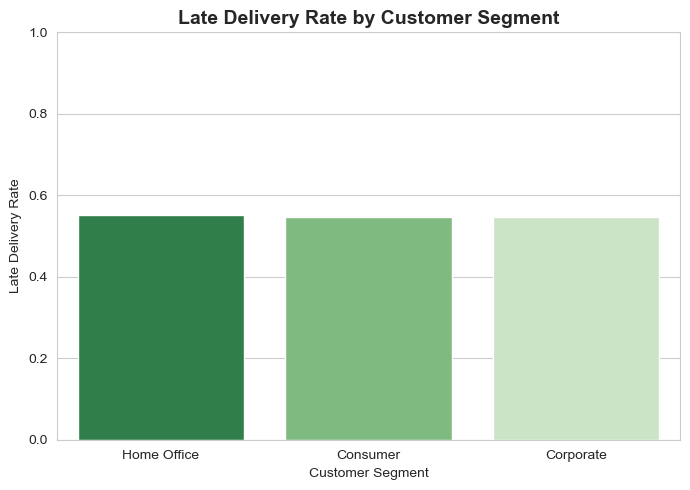

In [28]:
plt.figure(figsize=(7, 5))
seg_risk = df.groupby('Customer Segment')['Late_delivery_risk'].mean().sort_values(ascending=False)
ax = sns.barplot(x=seg_risk.index, y=seg_risk.values, hue=seg_risk.index,
                  palette='Greens_r', legend=False)
plt.ylim(0, 1)
plt.title('Late Delivery Rate by Customer Segment', fontsize=14, fontweight='bold')
plt.ylabel('Late Delivery Rate')
plt.xlabel('Customer Segment')
plt.tight_layout()
plt.savefig(f"{GRAPH_DIR}/05_customer_segment_vs_risk.png", dpi=150)
plt.show()

<h2 style="font-size:26px; color:#A16207; border-bottom:2px solid #FEF3C7; padding-bottom:7px;">
    <strong>Observation 5 — Customer Segment barely matters</strong>
</h2>

<div style="background:linear-gradient(135deg,#FEFCE8,#FFFBEB); border-left:5px solid #EAB308; padding:15px 18px; border-radius:8px; line-height:1.9;">

Home Office (<strong>55.1%</strong>), Consumer (<strong>54.8%</strong>), and Corporate (<strong>54.7%</strong>) are nearly identical — all sitting right at the overall base rate (~54.8%). Customer Segment on its own has almost no predictive power for delay risk.

</div>

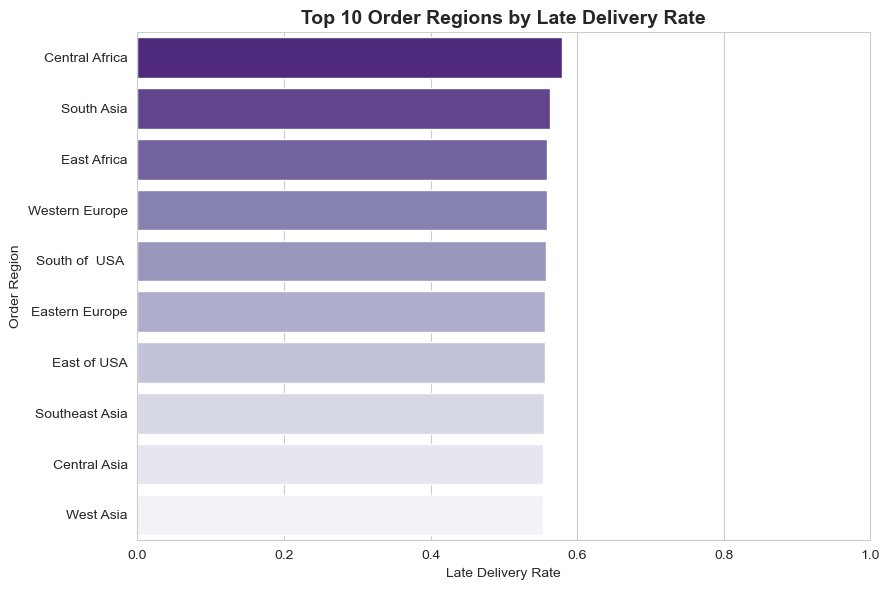

In [29]:
plt.figure(figsize=(9, 6))
region_risk = df.groupby('Order Region')['Late_delivery_risk'].mean().sort_values(ascending=False).head(10)
ax = sns.barplot(x=region_risk.values, y=region_risk.index, hue=region_risk.index,
                  palette='Purples_r', legend=False)
plt.xlim(0, 1)
plt.title('Top 10 Order Regions by Late Delivery Rate', fontsize=14, fontweight='bold')
plt.xlabel('Late Delivery Rate')
plt.ylabel('Order Region')
plt.tight_layout()
plt.savefig(f"{GRAPH_DIR}/06_order_region_vs_risk.png", dpi=150)
plt.show()

<h2 style="font-size:26px; color:#7E22CE; border-bottom:2px solid #F5F3FF; padding-bottom:7px;">
    <strong>Observation 6 — Region has a small, not-zero effect</strong>
</h2>

<div style="background:linear-gradient(135deg,#FAF5FF,#F5F3FF); border-left:5px solid #9333EA; padding:15px 18px; border-radius:8px; line-height:1.9;">

Even the highest-risk region (<strong>Central Africa, 58.0%</strong>) is only a few points above the lowest ones — nowhere near the ~57-point swing we saw from Shipping Mode. Region adds a small amount of signal but is a minor feature compared to shipping speed.

</div>

In [ ]:
# Feature Engineering

df.sample(4)

,Type,Days for shipment (scheduled),Benefit per order,Sales per customer,Late_delivery_risk,Category Name,Customer City,Customer Country,Customer Segment,Customer State,Department Name,Latitude,Longitude,Market,Order City,Order Country,Order Item Discount,Order Item Discount Rate,Order Item Product Price,Order Item Profit Ratio,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Order Region,Order State,Product Price,Shipping Mode
163433,DEBIT,4,27.389999,242.399994,1,Music,Hamtramck,EE. UU.,Home Office,MI,Discs Shop,42.399849,-83.058929,Pacific Asia,Bijapur,India,18.250000,0.07,260.649994,0.11,1,260.649994,242.399994,27.389999,South Asia,Karnataka,260.649994,Standard Class
83946,DEBIT,4,29.850000,106.589996,0,Men's Footwear,Van Nuys,EE. UU.,Consumer,CA,Apparel,34.195347,-118.448753,LATAM,Saltillo,México,23.400000,0.18,129.990005,0.28,1,129.990005,106.589996,29.850000,Central America,Coahuila,129.990005,Standard Class
15211,TRANSFER,4,87.110001,239.960007,1,Cleats,Princeton,EE. UU.,Consumer,NJ,Apparel,40.357422,-74.648422,Europe,Birmingham,Reino Unido,59.990002,0.20,59.990002,0.36,5,299.950012,239.960007,87.110001,Northern Europe,Inglaterra,59.990002,Standard Class
1294,PAYMENT,2,49.000000,245.000000,1,Women's Apparel,Caguas,Puerto Rico,Home Office,PR,Golf,18.296879,-66.370590,LATAM,Santo Domingo,República Dominicana,5.000000,0.02,50.000000,0.20,5,250.000000,245.000000,49.000000,Caribbean,Santo Domingo,50.000000,Second Class


In [ ]:
X = df.drop(columns = 'Late_delivery_risk')

y = df['Late_delivery_risk']

In [ ]:
df.sample(3)

,Type,Days for shipment (scheduled),Benefit per order,Sales per customer,Late_delivery_risk,Category Name,Customer City,Customer Country,Customer Segment,Customer State,Department Name,Latitude,Longitude,Market,Order City,Order Country,Order Item Discount,Order Item Discount Rate,Order Item Product Price,Order Item Profit Ratio,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Order Region,Order State,Product Price,Shipping Mode
55773,DEBIT,4,-329.779999,193.990005,0,Water Sports,Caguas,Puerto Rico,Consumer,PR,Fan Shop,18.224686,-66.370537,LATAM,Tlaquepaque,México,6.00,0.03,199.990005,-1.70,1,199.990005,193.990005,-329.779999,Central America,Jalisco,199.990005,Standard Class
162244,TRANSFER,4,35.660000,101.879997,0,Electronics,Caguas,Puerto Rico,Consumer,PR,Footwear,18.247580,-66.025314,LATAM,El Limón,Venezuela,10.08,0.09,27.990000,0.35,4,111.959999,101.879997,35.660000,South America,Aragua,27.990000,Standard Class
73051,DEBIT,4,50.959999,195.990005,0,Water Sports,Colorado Springs,EE. UU.,Corporate,CO,Fan Shop,38.905815,-104.775154,Pacific Asia,Corlu,Turquía,4.00,0.02,199.990005,0.26,1,199.990005,195.990005,50.959999,West Asia,Tekirdag,199.990005,Standard Class


In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop('Late_delivery_risk', axis=1)
y = df['Late_delivery_risk']

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

X_valid, X_test, y_valid, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

In [ ]:
print("Training Set   :", X_train.shape)
print("Validation Set :", X_valid.shape)
print("Testing Set    :", X_test.shape)

print()

print("Training Labels   :", y_train.shape)
print("Validation Labels :", y_valid.shape)
print("Testing Labels    :", y_test.shape)

Training Set   : (126363, 27)
Validation Set : (27078, 27)
Testing Set    : (27078, 27)

Training Labels   : (126363,)
Validation Labels : (27078,)
Testing Labels    : (27078,)


In [ ]:
#encoding

categorical_columns = X_train.select_dtypes(include="object").columns

categorical_columns

numerical_columns = X_train.select_dtypes(include=["number"]).columns

numerical_columns

Index(['Days for shipment (scheduled)', 'Benefit per order',
       'Sales per customer', 'Latitude', 'Longitude', 'Order Item Discount',
       'Order Item Discount Rate', 'Order Item Product Price',
       'Order Item Profit Ratio', 'Order Item Quantity', 'Sales',
       'Order Item Total', 'Order Profit Per Order', 'Product Price'],
      dtype='object')

In [ ]:
#encoding categorical column

from sklearn.preprocessing import OrdinalEncoder

encoder = OrdinalEncoder(
    handle_unknown="use_encoded_value",
    unknown_value=-1
)

X_train[categorical_columns] = encoder.fit_transform(
    X_train[categorical_columns]
)

X_valid[categorical_columns] = encoder.transform(
    X_valid[categorical_columns]
)

X_test[categorical_columns] = encoder.transform(
    X_test[categorical_columns]
)

In [ ]:
#scaling

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_valid = scaler.transform(X_valid)

X_test = scaler.transform(X_test)

In [ ]:
# Convert to Tensors

import torch

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_valid_tensor = torch.tensor(X_valid, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train.to_numpy(), dtype=torch.float32).reshape(-1, 1)
y_valid_tensor = torch.tensor(y_valid.to_numpy(), dtype=torch.float32).reshape(-1, 1)
y_test_tensor = torch.tensor(y_test.to_numpy(), dtype=torch.float32).reshape(-1, 1)

In [ ]:
type(y_test)

print(type(X_train))
print(type(y_train))

print(X_train.shape)
print(y_train.shape)

<class 'numpy.ndarray'>
<class 'pandas.core.series.Series'>
(126363, 27)
(126363,)


In [ ]:
# Create Dataset & DataLoader

from torch.utils.data import DataLoader
from torch.utils.data import TensorDataset

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
valid_dataset = TensorDataset(X_valid_tensor, y_valid_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

In [ ]:
#dataloader

from torch.utils.data import DataLoader

train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=64,shuffle=True)

valid_loader = DataLoader(
    dataset=valid_dataset,
    batch_size=64,shuffle=False)

test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=64,
    shuffle=False
)

In [ ]:
# Design Neural Network Architecture
# problem is binary so outout feature will be 2 then lets check no. of input features = 27

X_train.shape[1]


27

In [ ]:
import torch
import torch.nn as nn


class ShipSenseModel(nn.Module):

    def __init__(self):
        super().__init__()

        # Input Layer → Hidden Layer 1
        self.fc1 = nn.Linear(27, 64)

        # Hidden Layer 2
        self.fc2 = nn.Linear(64, 32)

        # Hidden Layer 3
        self.fc3 = nn.Linear(32, 16)

        # Hidden Layer 4
        self.fc4 = nn.Linear(16, 8)

        # Output Layer
        self.fc5 = nn.Linear(8, 1)

        self.relu = nn.ReLU()

    def forward(self, x):

        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.relu(self.fc3(x))
        x = self.relu(self.fc4(x))

        x = self.fc5(x)

        return x


model = ShipSenseModel()

print(model)

ShipSenseModel(
  (fc1): Linear(in_features=27, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=32, bias=True)
  (fc3): Linear(in_features=32, out_features=16, bias=True)
  (fc4): Linear(in_features=16, out_features=8, bias=True)
  (fc5): Linear(in_features=8, out_features=1, bias=True)
  (relu): ReLU()
)


In [ ]:
print(model)

ShipSenseModel(
  (fc1): Linear(in_features=27, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=32, bias=True)
  (fc3): Linear(in_features=32, out_features=16, bias=True)
  (fc4): Linear(in_features=16, out_features=8, bias=True)
  (fc5): Linear(in_features=8, out_features=1, bias=True)
  (relu): ReLU()
)


In [ ]:
#now creating loss and optimiser

import torch.optim as optim

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(),lr=0.001)

In [ ]:
model.parameters

<bound method Module.parameters of ShipSenseModel(
  (fc1): Linear(in_features=27, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=32, bias=True)
  (fc3): Linear(in_features=32, out_features=16, bias=True)
  (fc4): Linear(in_features=16, out_features=8, bias=True)
  (fc5): Linear(in_features=8, out_features=1, bias=True)
  (relu): ReLU()
)>

In [ ]:
#training loop

model.train()
epochs = 20

for epoch in range(epochs):
    epochs_loss = 0
    for X_batch, y_batch in train_loader:
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epochs_loss = epochs_loss + loss.item()
    avg_loss = epochs_loss / len(train_loader)
    print(f"Epoch [{epoch+1}/{epochs}] | Loss: {avg_loss}")



Epoch [1/20] | Loss: 0.5820382947559598
Epoch [2/20] | Loss: 0.5617406014400192
Epoch [3/20] | Loss: 0.5593247376061693
Epoch [4/20] | Loss: 0.5579505986050715
Epoch [5/20] | Loss: 0.5570467503915859
Epoch [6/20] | Loss: 0.5564011996607238
Epoch [7/20] | Loss: 0.555850544051279
Epoch [8/20] | Loss: 0.5550348768958563
Epoch [9/20] | Loss: 0.5545383267613906
Epoch [10/20] | Loss: 0.5539520358586613
Epoch [11/20] | Loss: 0.5531324644481079
Epoch [12/20] | Loss: 0.5525034421908704
Epoch [13/20] | Loss: 0.5515837720526925
Epoch [14/20] | Loss: 0.5510966879053961
Epoch [15/20] | Loss: 0.5505652852148949
Epoch [16/20] | Loss: 0.5498483309715609
Epoch [17/20] | Loss: 0.5490543826773197
Epoch [18/20] | Loss: 0.5484758167327205
Epoch [19/20] | Loss: 0.5477241867252542
Epoch [20/20] | Loss: 0.5470409577405906


In [ ]:
#next step : Validation
model.eval()

val_loss = 0.0

with torch.no_grad():

    for X_batch, y_batch in valid_loader:

        outputs = model(X_batch)

        loss = criterion(outputs, y_batch)

        val_loss += loss.item()

avg_val_loss = val_loss / len(valid_loader)

print(f"Validation Loss: {avg_val_loss}")

Validation Loss: 0.5558275948717909


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [ ]:
model.eval()


val_loss = 0.0

all_predictions = []
all_targets = []

In [ ]:
with torch.no_grad():

    for X_batch, y_batch in valid_loader:

        outputs = model(X_batch)

        loss = criterion(outputs, y_batch)

        val_loss += loss.item()

        probabilities = torch.sigmoid(outputs)

        predictions = (probabilities >= 0.5).float()

        all_predictions.extend(
            predictions.cpu().numpy().flatten()
        )

        all_targets.extend(
            y_batch.cpu().numpy().flatten()
        )

In [ ]:
#Average validation loss

avg_val_loss = val_loss / len(valid_loader)

In [ ]:
#  Calculate validation metrics

val_accuracy = accuracy_score(
    all_targets,
    all_predictions
)

val_precision = precision_score(
    all_targets,
    all_predictions,
    zero_division=0
)

val_recall = recall_score(
    all_targets,
    all_predictions,
    zero_division=0
)

val_f1 = f1_score(
    all_targets,
    all_predictions,
    zero_division=0
)



cm = confusion_matrix(
    all_targets,
    all_predictions
)


#now print all the
print("========== VALIDATION RESULTS ==========")

print(f"Validation Loss      : {avg_val_loss:.4f}")
print(f"Validation Accuracy  : {val_accuracy:.4f}")
print(f"Validation Precision : {val_precision:.4f}")
print(f"Validation Recall    : {val_recall:.4f}")
print(f"Validation F1 Score  : {val_f1:.4f}")

print("\nConfusion Matrix:")
print(cm)



print("\nClassification Report:")
print(
    classification_report(
        all_targets,
        all_predictions,
        target_names=["Not Late", "Late"],
        zero_division=0
    )
)

========== VALIDATION RESULTS ==========
Validation Loss      : 0.5558
Validation Accuracy  : 0.6955
Validation Precision : 0.8427
Validation Recall    : 0.5467
Validation F1 Score  : 0.6632

Confusion Matrix:
[[10716  1515]
 [ 6730  8117]]

Classification Report:
              precision    recall  f1-score   support

    Not Late       0.61      0.88      0.72     12231
        Late       0.84      0.55      0.66     14847

    accuracy                           0.70     27078
   macro avg       0.73      0.71      0.69     27078
weighted avg       0.74      0.70      0.69     27078



In [ ]:
#now next : Hyperparameter Tuning
import optuna

class OptunaShipSenseModel(nn.Module):

    def __init__(self, input_features, hidden1, hidden2, hidden3, dropout):

        super().__init__()

        self.network = nn.Sequential(

            nn.Linear(input_features, hidden1),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(hidden1, hidden2),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(hidden2, hidden3),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(hidden3, 1)
        )

    def forward(self, x):

        return self.network(x)

In [ ]:
import random

TUNE_SUBSET_SIZE = 40000 

def objective(trial):

    hidden1 = trial.suggest_categorical("hidden1", [32, 64, 96])

    hidden2 = trial.suggest_categorical("hidden2", [16, 32, 48])

    hidden3 = trial.suggest_categorical("hidden3", [8, 16, 24])

    dropout = trial.suggest_float("dropout", 0.0, 0.4, step=0.2)

    learning_rate = trial.suggest_float("learning_rate", 1e-4, 1e-2, log=True)

    batch_size = trial.suggest_categorical("batch_size", [128, 256])

    epochs = 8  # fixed, not searched



    # random subsample of the training set for this trial 
    subset_size = min(TUNE_SUBSET_SIZE, len(train_dataset))
    subset_indices = random.sample(range(len(train_dataset)), subset_size)
    train_subset = torch.utils.data.Subset(train_dataset, subset_indices)

    train_loader_optuna = DataLoader(
        train_subset,
        batch_size=batch_size,
        shuffle=True
    )

    valid_loader_optuna = DataLoader(
        valid_dataset,
        batch_size=batch_size,
        shuffle=False
    )



    model = OptunaShipSenseModel(
        input_features=X_train_tensor.shape[1],
        hidden1=hidden1,
        hidden2=hidden2,
        hidden3=hidden3,
        dropout=dropout
    ).to(device)



    criterion = nn.BCEWithLogitsLoss()

    optimizer = optim.Adam(
        model.parameters(),
        lr=learning_rate
    )



    for epoch in range(epochs):

        model.train()

        for X_batch, y_batch in train_loader_optuna:

            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            outputs = model(X_batch)

            loss = criterion(
                outputs,
                y_batch
            )

            optimizer.zero_grad()

            loss.backward()

            optimizer.step()

        # ---- pruning check (stop bad trials early) ----
        model.eval()
        epoch_preds, epoch_targets = [], []
        with torch.no_grad():
            for X_batch, y_batch in valid_loader_optuna:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                probs = torch.sigmoid(model(X_batch))
                preds = (probs >= 0.5).float()
                epoch_preds.extend(preds.cpu().numpy().flatten())
                epoch_targets.extend(y_batch.cpu().numpy().flatten())

        epoch_f1 = f1_score(epoch_targets, epoch_preds, zero_division=0)
        trial.report(epoch_f1, epoch)

        if trial.should_prune():
            raise optuna.TrialPruned()



    model.eval()

    all_predictions = []
    all_targets = []

    with torch.no_grad():

        for X_batch, y_batch in valid_loader_optuna:

            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            outputs = model(X_batch)

            probabilities = torch.sigmoid(outputs)

            predictions = (
                probabilities >= 0.5
            ).float()

            all_predictions.extend(
                predictions.cpu().numpy().flatten()
            )

            all_targets.extend(
                y_batch.cpu().numpy().flatten()
            )



    validation_f1 = f1_score(
        all_targets,
        all_predictions,
        zero_division=0
    )


    return validation_f1


In [ ]:

study = optuna.create_study(
    direction="maximize",
    pruner=optuna.pruners.MedianPruner(n_startup_trials=3, n_warmup_steps=3)
)

study.optimize(
    objective,
    n_trials=10,
    timeout=1800
)


[I 2026-08-25 05:18:56,253] A new study created in memory with name: no-name-e68e0ed6-882e-4bee-9afc-97ce13fca122
[I 2026-08-25 05:19:03,344] Trial 0 finished with value: 0.6622630672027571 and parameters: {'hidden1': 64, 'hidden2': 48, 'hidden3': 16, 'dropout': 0.4, 'learning_rate': 0.0017922471868430285, 'batch_size': 256}. Best is trial 0 with value: 0.6622630672027571.
[I 2026-08-25 05:19:11,003] Trial 1 finished with value: 0.663636735863735 and parameters: {'hidden1': 64, 'hidden2': 16, 'hidden3': 16, 'dropout': 0.2, 'learning_rate': 0.0027195092970246464, 'batch_size': 256}. Best is trial 1 with value: 0.663636735863735.
[I 2026-08-25 05:19:21,628] Trial 2 finished with value: 0.6772692009309542 and parameters: {'hidden1': 96, 'hidden2': 32, 'hidden3': 24, 'dropout': 0.4, 'learning_rate': 0.00023951032722623506, 'batch_size': 128}. Best is trial 2 with value: 0.6772692009309542.
[I 2026-08-25 05:19:30,942] Trial 3 finished with value: 0.6717019930401772 and parameters: {'hidden1

In [ ]:
print("========== OPTUNA RESULTS ==========")

print(
    f"Best Validation F1 Score: "
    f"{study.best_value:.4f}"
)

print("\nBest Hyperparameters:")

for parameter, value in study.best_params.items():

    print(
        f"{parameter}: {value}"
    )

========== OPTUNA RESULTS ==========
Best Validation F1 Score: 0.6785

Best Hyperparameters:
hidden1: 64
hidden2: 32
hidden3: 8
dropout: 0.0
learning_rate: 0.0008555614148746053
batch_size: 256


workflow : Baseline ANN
     ↓
Validation
     ↓
Optuna Hyperparameter Tuning  ← THESE 5 CELLS
     ↓
Best Hyperparameters
     ↓
Train Final Optimized Model
     ↓
Validation
     ↓
Test Evaluation

<div style="
    background: linear-gradient(135deg, #450A0A, #7F1D1D, #991B1B);
    border: 2px solid #F87171;
    border-radius: 16px;
    padding: 24px;
    text-align: center;
    box-shadow: 0 8px 25px rgba(127, 29, 29, 0.30);
">

<h1 style="
    margin: 0;
    font-size: 34px;
    color: #FEF2F2;
    letter-spacing: 1px;
">
    Project Discontinued
</h1>

<p style="color:#FECACA; font-size:16px; margin-bottom:0;">
    Project discontinued because my laptop isn't capable of training this dataset.
</p>

</div>

<h3 style="color:#991B1B; font-size:23px;">
    Reason
</h3>

<div style="
    background:#FEF2F2;
    border-left:5px solid #DC2626;
    padding:13px 17px;
    border-radius:8px;
">

<strong>Repeatedly freezing and lagging</strong> while training the model or
performing computationally intensive operations.

</div>

<h3 style="color:#1E3A8A; font-size:23px;">
    What I Learned
</h3>

<div style="
    background:linear-gradient(135deg,#EFF6FF,#F5F3FF);
    border-left:5px solid #2563EB;
    padding:16px 18px;
    border-radius:8px;
    line-height:1.8;
">

<ul>
<li>Learned the <strong>complete Deep Learning project pipeline</strong>.</li>

<li>Learned how to build a Deep Learning project from start to finish.</li>

<li>Learned <strong>hyperparameter tuning</strong>.</li>

<li>Learned <strong>model evaluation and validation</strong>.</li>

<li>Learned how to perform <strong>data collection</strong>.</li>

<li>Instead of taking a ready-made dataset from Kaggle, I
<strong>collected and prepared the dataset myself</strong> for model training.</li>
</ul>

</div>

<blockquote>

<strong>Although the project was discontinued, it was not wasted work.</strong>
The project provided valuable hands-on experience with the complete Deep
Learning workflow.

</blockquote>

<div style="
    background:linear-gradient(135deg,#052E16,#166534,#14532D);
    border:2px solid #4ADE80;
    border-radius:14px;
    padding:22px;
    text-align:center;
    margin-top:20px;
">

<h2 style="margin:0; color:#F0FDF4; font-size:25px;">
    Thank You
</h2>

<p style="color:#DCFCE7; font-size:16px;">
    Thanks a lot for reading this notebook.
</p>

</div>

<div style="
    background: linear-gradient(135deg, #052E16, #166534, #14532D);
    border: 2px solid #4ADE80;
    border-radius: 16px;
    padding: 24px;
    text-align: center;
    box-shadow: 0 8px 25px rgba(22, 101, 52, 0.30);
">

<h1 style="
    margin: 0;
    font-size: 32px;
    color: #F0FDF4;
    letter-spacing: 1px;
">
    Update — Continuing the Same Project Again on Google Colab (GPU)
</h1>

</div>

<p style="font-size:16px; line-height:1.8;">

The section above (<strong>baseline model → Optuna tuning</strong>) represents
the original work completed locally. The project was temporarily limited by the
laptop's available compute resources, which caused repeated freezing and lagging
during the heavier training and hyperparameter-tuning stages.

</p>

<div style="
    background:linear-gradient(135deg,#EFF6FF,#F5F3FF);
    border-left:5px solid #2563EB;
    padding:14px 18px;
    border-radius:8px;
    line-height:1.8;
">

<strong>To complete the project:</strong> the same pipeline was moved to
<strong>Google Colab with GPU acceleration</strong>.

A lighter and more practical Optuna search was used, with
<strong>fixed epochs, smaller search spaces, a subsampled tuning dataset,
and pruning</strong> to reduce unnecessary computation.

</div>

<h3 style="color:#1E3A8A;">Final Model</h3>

<p style="line-height:1.8;">

The final model was trained using the <strong>best hyperparameters</strong>
found during tuning on the <strong>complete training set</strong>.

Its performance was evaluated on the <strong>untouched test set</strong>, and
all required deployment artifacts were saved:

</p>

<ul style="line-height:1.9;">

<li><strong>Model weights</strong></li>
<li><strong>Scaler</strong></li>
<li><strong>Encoder</strong></li>
<li><strong>Feature order</strong></li>

</ul>

<div style="
    background:#ECFDF5;
    border-left:5px solid #16A34A;
    padding:14px 18px;
    border-radius:8px;
    line-height:1.8;
">

<strong>Key Conclusion</strong><br><br>

This confirms that the project was <strong>not discontinued because of a
modeling issue</strong>. The main limitation was the available local computing
resources.

Moving the workload to a <strong>GPU-enabled environment</strong> allowed the
same approach to be completed successfully.

</div>

> <strong>Local limitation → Google Colab GPU → Optimized tuning → Final model → Evaluation → Deployment artifacts saved</strong>


In [ ]:
# Final model — best hyperparameters from Optuna, trained on the FULL training set

best_params = study.best_params
print("Training final model with:", best_params)

final_epochs = 20
final_model = OptunaShipSenseModel(
    input_features=X_train_tensor.shape[1],
    hidden1=best_params["hidden1"],
    hidden2=best_params["hidden2"],
    hidden3=best_params["hidden3"],
    dropout=best_params["dropout"]
).to(device)

final_criterion = nn.BCEWithLogitsLoss()
final_optimizer = optim.Adam(final_model.parameters(), lr=best_params["learning_rate"])

final_train_loader = DataLoader(
    train_dataset,
    batch_size=best_params["batch_size"],
    shuffle=True
)

final_valid_loader = DataLoader(
    valid_dataset,
    batch_size=best_params["batch_size"],
    shuffle=False
)

for epoch in range(final_epochs):

    final_model.train()
    epoch_loss = 0.0

    for X_batch, y_batch in final_train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        outputs = final_model(X_batch)
        loss = final_criterion(outputs, y_batch)

        final_optimizer.zero_grad()
        loss.backward()
        final_optimizer.step()

        epoch_loss += loss.item()

    avg_epoch_loss = epoch_loss / len(final_train_loader)
    print(f"Epoch [{epoch+1}/{final_epochs}] | Train Loss: {avg_epoch_loss:.4f}")


Training final model with: {'hidden1': 64, 'hidden2': 32, 'hidden3': 8, 'dropout': 0.0, 'learning_rate': 0.0008555614148746053, 'batch_size': 256}
Epoch [1/20] | Train Loss: 0.6129
Epoch [2/20] | Train Loss: 0.5705
Epoch [3/20] | Train Loss: 0.5628
Epoch [4/20] | Train Loss: 0.5605
Epoch [5/20] | Train Loss: 0.5588
Epoch [6/20] | Train Loss: 0.5575
Epoch [7/20] | Train Loss: 0.5568
Epoch [8/20] | Train Loss: 0.5561
Epoch [9/20] | Train Loss: 0.5556
Epoch [10/20] | Train Loss: 0.5551
Epoch [11/20] | Train Loss: 0.5547
Epoch [12/20] | Train Loss: 0.5539
Epoch [13/20] | Train Loss: 0.5536
Epoch [14/20] | Train Loss: 0.5533
Epoch [15/20] | Train Loss: 0.5526
Epoch [16/20] | Train Loss: 0.5521
Epoch [17/20] | Train Loss: 0.5517
Epoch [18/20] | Train Loss: 0.5514
Epoch [19/20] | Train Loss: 0.5510
Epoch [20/20] | Train Loss: 0.5505


In [ ]:
# Final validation check 

final_model.eval()
val_predictions, val_targets = [], []

with torch.no_grad():
    for X_batch, y_batch in final_valid_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        probs = torch.sigmoid(final_model(X_batch))
        preds = (probs >= 0.5).float()
        val_predictions.extend(preds.cpu().numpy().flatten())
        val_targets.extend(y_batch.cpu().numpy().flatten())

print("========== FINAL MODEL — VALIDATION RESULTS ==========")
print(f"Accuracy  : {accuracy_score(val_targets, val_predictions):.4f}")
print(f"Precision : {precision_score(val_targets, val_predictions, zero_division=0):.4f}")
print(f"Recall    : {recall_score(val_targets, val_predictions, zero_division=0):.4f}")
print(f"F1 Score  : {f1_score(val_targets, val_predictions, zero_division=0):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(val_targets, val_predictions))


========== FINAL MODEL — VALIDATION RESULTS ==========
Accuracy  : 0.6964
Precision : 0.8203
Recall    : 0.5716
F1 Score  : 0.6737

Confusion Matrix:
[[10372  1859]
 [ 6361  8486]]


In [ ]:
# Test set evaluation 
test_loader_final = DataLoader(
    test_dataset,
    batch_size=best_params["batch_size"],
    shuffle=False
)

final_model.eval()
test_predictions, test_targets, test_probs_all = [], [], []

with torch.no_grad():
    for X_batch, y_batch in test_loader_final:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        probs = torch.sigmoid(final_model(X_batch))
        preds = (probs >= 0.5).float()
        test_predictions.extend(preds.cpu().numpy().flatten())
        test_targets.extend(y_batch.cpu().numpy().flatten())
        test_probs_all.extend(probs.cpu().numpy().flatten())

print("========== FINAL MODEL — TEST RESULTS ==========")
print(f"Accuracy  : {accuracy_score(test_targets, test_predictions):.4f}")
print(f"Precision : {precision_score(test_targets, test_predictions, zero_division=0):.4f}")
print(f"Recall    : {recall_score(test_targets, test_predictions, zero_division=0):.4f}")
print(f"F1 Score  : {f1_score(test_targets, test_predictions, zero_division=0):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(test_targets, test_predictions))
print("\nClassification Report:")
print(classification_report(test_targets, test_predictions, target_names=["Not Late", "Late"], zero_division=0))


========== FINAL MODEL — TEST RESULTS ==========
Accuracy  : 0.6985
Precision : 0.8229
Recall    : 0.5734
F1 Score  : 0.6759

Confusion Matrix:
[[10400  1832]
 [ 6333  8513]]

Classification Report:
              precision    recall  f1-score   support

    Not Late       0.62      0.85      0.72     12232
        Late       0.82      0.57      0.68     14846

    accuracy                           0.70     27078
   macro avg       0.72      0.71      0.70     27078
weighted avg       0.73      0.70      0.69     27078



In [ ]:
# Save everything needed for deployment: model weights, scaler, encoder,
# best hyperparameters, and the exact feature order/column lists used at
# training time (needed so a Streamlit app can preprocess new input identically)

import joblib
import os

SAVE_DIR = "/content/shipsense_artifacts"
os.makedirs(SAVE_DIR, exist_ok=True)

torch.save(final_model.state_dict(), f"{SAVE_DIR}/shipsense_model.pth")
joblib.dump(scaler, f"{SAVE_DIR}/scaler.pkl")
joblib.dump(encoder, f"{SAVE_DIR}/encoder.pkl")
joblib.dump(best_params, f"{SAVE_DIR}/best_hyperparameters.pkl")
joblib.dump(list(categorical_columns), f"{SAVE_DIR}/categorical_columns.pkl")
joblib.dump(list(numerical_columns), f"{SAVE_DIR}/numerical_columns.pkl")
joblib.dump(list(X.columns), f"{SAVE_DIR}/feature_order.pkl")

print("Saved to:", SAVE_DIR)
print(os.listdir(SAVE_DIR))

import shutil
shutil.make_archive("/content/shipsense_artifacts", "zip", SAVE_DIR)
print("\nZipped: /content/shipsense_artifacts.zip — download this from the Files panel.")


Saved to: /content/shipsense_artifacts
['numerical_columns.pkl', 'best_hyperparameters.pkl', 'shipsense_model.pth', 'feature_order.pkl', 'encoder.pkl', 'scaler.pkl', 'categorical_columns.pkl']

Zipped: /content/shipsense_artifacts.zip — download this from the Files panel.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


| File                      | Purpose                                               |
| ------------------------- | ----------------------------------------------------- |
| `encoder.pkl`             | Converts categorical values into numbers              |
| `scaler.pkl`              | Applies the same feature scaling used during training |
| `feature_order.pkl`       | Ensures columns are in the exact expected order       |
| `categorical_columns.pkl` | Tells us which columns are categorical                |
| `numerical_columns.pkl`   | Tells us which columns are numerical                  |
